# San Francisco Airbnb Listing Performance Analysis

## Business Question: Which listing and host features are associated with higher occupancy for Airbnb listings in San Francisco?

## 1. Project Overview

### Project Context

This project focuses on listing performance and the analysis of the factors that drive occupancy. The goal is to identify patterns in listing structure, host behavior, and location that are associated with stronger occupancy outcomes in San Francisco.

### Data Notes

The dataset includes listing details, review metrics, host signals, and Inside Airbnb occupancy estimates. In this dataset, `price` and `estimated_revenue_l365d` are missing, so the analysis focuses on occupancy rather than pricing or revenue.

## 2. Data Preparation

### Cleaning Strategy

The cleaning approach is intentionally light. Numerical host flags are converted to numeric values, percentage fields are converted to numeric form, and missing values are retained unless a specific analysis requires that variable. This preserves as much of the dataset as possible while keeping the transformations easy to explain.

In [29]:
#Importing Libraries and dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("sf_listings.csv")


In [30]:
# Inspect the full raw dataset to understand column types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7535 entries, 0 to 7534
Data columns (total 85 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            7535 non-null   int64  
 1   listing_url                                   7535 non-null   object 
 2   scrape_id                                     7535 non-null   int64  
 3   last_scraped                                  7535 non-null   object 
 4   source                                        7535 non-null   object 
 5   name                                          7535 non-null   object 
 6   description                                   7445 non-null   object 
 7   neighborhood_overview                         4168 non-null   object 
 8   picture_url                                   7535 non-null   object 
 9   host_id                                       7535 non-null   i

In [31]:
#Picking the columns most useful for analysis
cols = [
    'id',
    'name',
    'room_type',
    'property_type',
    'neighbourhood_cleansed',
    'accommodates',
    'bedrooms',
    'beds',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'review_scores_rating',
    'host_is_superhost',
    'instant_bookable',
    'host_response_rate',
    'host_acceptance_rate',
    'calculated_host_listings_count',
    'availability_365',
    'estimated_occupancy_l365d'
]

airbnb = df[cols].copy()
airbnb.head()

,id,name,room_type,property_type,neighbourhood_cleansed,accommodates,bedrooms,beds,minimum_nights,number_of_reviews,reviews_per_month,review_scores_rating,host_is_superhost,instant_bookable,host_response_rate,host_acceptance_rate,calculated_host_listings_count,availability_365,estimated_occupancy_l365d
0,958,"Bright, Modern Garden Unit - 1BR/1BTH",Entire home/apt,Entire serviced apartment,Western Addition,3,1.0,2.0,2,507,2.54,4.88,t,f,92%,100%,1,228,255
1,5858,Creative Sanctuary,Entire home/apt,Entire rental unit,Bernal Heights,4,2.0,2.0,30,105,0.52,4.87,f,f,80%,79%,1,365,0
2,8142,*FriendlyRoom Apt. Style -UCSF/USF - San Franc...,Private room,Private room in rental unit,Haight Ashbury,1,3.0,1.0,32,10,0.07,4.70,t,f,100%,86%,20,362,0
3,8339,Historic Alamo Square Victorian,Entire home/apt,Entire condo,Western Addition,2,1.0,1.0,9,25,0.13,4.86,f,f,100%,0%,1,339,0
4,10537,Elegant & Cozy w/City views. Private room: Purple,Private room,Private room,Bayview,2,1.0,1.0,1,46,0.24,4.98,t,f,100%,96%,3,365,132


In [32]:
# Verify the smaller analysis dataframe before cleaning key fields
airbnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7535 entries, 0 to 7534
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              7535 non-null   int64  
 1   name                            7535 non-null   object 
 2   room_type                       7535 non-null   object 
 3   property_type                   7535 non-null   object 
 4   neighbourhood_cleansed          7535 non-null   object 
 5   accommodates                    7535 non-null   int64  
 6   bedrooms                        7096 non-null   float64
 7   beds                            5692 non-null   float64
 8   minimum_nights                  7535 non-null   int64  
 9   number_of_reviews               7535 non-null   int64  
 10  reviews_per_month               5862 non-null   float64
 11  review_scores_rating            5862 non-null   float64
 12  host_is_superhost               75

In [33]:
# Convert binary flags and percentage fields into numeric values for analysis
airbnb[['host_is_superhost', 'instant_bookable']] = (
    airbnb[['host_is_superhost', 'instant_bookable']]
    .replace({'t': 1, 'f': 0})
)

airbnb[['host_response_rate', 'host_acceptance_rate']] = (
    airbnb[['host_response_rate', 'host_acceptance_rate']]
    .replace('%', '', regex=True)
    .apply(pd.to_numeric, errors='coerce')
)



C:\Users\Matt\AppData\Local\Temp\ipykernel_11704\3137770725.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({'t': 1, 'f': 0})


In [34]:
# Check which analysis columns still have missing values after basic cleaning
airbnb.isnull().sum().sort_values(ascending=False)

beds                              1843
reviews_per_month                 1673
review_scores_rating              1673
host_response_rate                1298
host_acceptance_rate              1022
bedrooms                           439
id                                   0
room_type                            0
name                                 0
accommodates                         0
property_type                        0
number_of_reviews                    0
minimum_nights                       0
neighbourhood_cleansed               0
host_is_superhost                    0
instant_bookable                     0
calculated_host_listings_count       0
availability_365                     0
estimated_occupancy_l365d            0
dtype: int64

In [35]:
# Create occupancy measurements that will be used as the main outcome throughout the notebook
airbnb['occupied_nights'] = airbnb['estimated_occupancy_l365d']
airbnb['occupancy_rate'] = airbnb['occupied_nights'] / 365

airbnb[['occupied_nights', 'occupancy_rate']].describe()

,occupied_nights,occupancy_rate
count,7535.000000,7535.000000
mean,86.852953,0.237953
std,99.200424,0.271782
min,0.000000,0.000000
25%,0.000000,0.000000
50%,44.000000,0.120548
75%,180.000000,0.493151
max,255.000000,0.698630


In [36]:
# Re-check data types and null counts after creating the new occupancy metrics
airbnb.info()
airbnb.isna().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7535 entries, 0 to 7534
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              7535 non-null   int64  
 1   name                            7535 non-null   object 
 2   room_type                       7535 non-null   object 
 3   property_type                   7535 non-null   object 
 4   neighbourhood_cleansed          7535 non-null   object 
 5   accommodates                    7535 non-null   int64  
 6   bedrooms                        7096 non-null   float64
 7   beds                            5692 non-null   float64
 8   minimum_nights                  7535 non-null   int64  
 9   number_of_reviews               7535 non-null   int64  
 10  reviews_per_month               5862 non-null   float64
 11  review_scores_rating            5862 non-null   float64
 12  host_is_superhost               75

beds                              1843
reviews_per_month                 1673
review_scores_rating              1673
host_response_rate                1298
host_acceptance_rate              1022
bedrooms                           439
neighbourhood_cleansed               0
room_type                            0
name                                 0
id                                   0
property_type                        0
minimum_nights                       0
accommodates                         0
host_is_superhost                    0
number_of_reviews                    0
instant_bookable                     0
calculated_host_listings_count       0
availability_365                     0
estimated_occupancy_l365d            0
occupied_nights                      0
occupancy_rate                       0
dtype: int64

## 3. Exploratory Analysis

### 1. How is occupancy distributed?

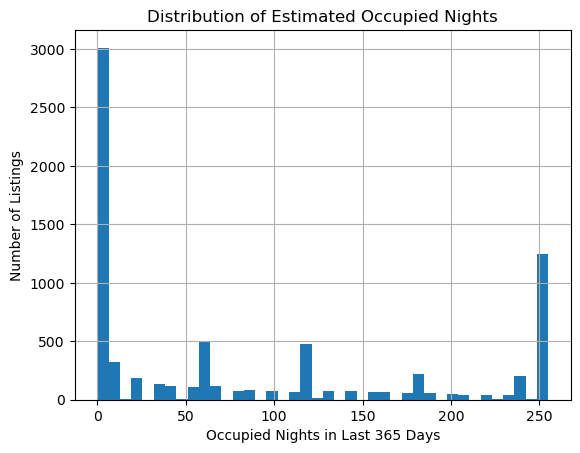

In [37]:
# Visualize how occupied nights are distributed across listings
airbnb['occupied_nights'].hist(bins=40)
plt.title("Distribution of Estimated Occupied Nights")
plt.xlabel("Occupied Nights in Last 365 Days")
plt.ylabel("Number of Listings")
plt.show()

The distribution appears to be skewed towards 0 nights and 250, with many listings clustered at relatively low occupancy and a smaller group achieving much stronger booking performance. This suggests that occupancy is uneven across the San Francisco market, making comparing specific factors more useful than relying on a single overall average.

### 2. Which listing types appear to perform best?

This section compares occupancy across room types and adds listing counts so high-performing but very small categories can be interpreted more cautiously.

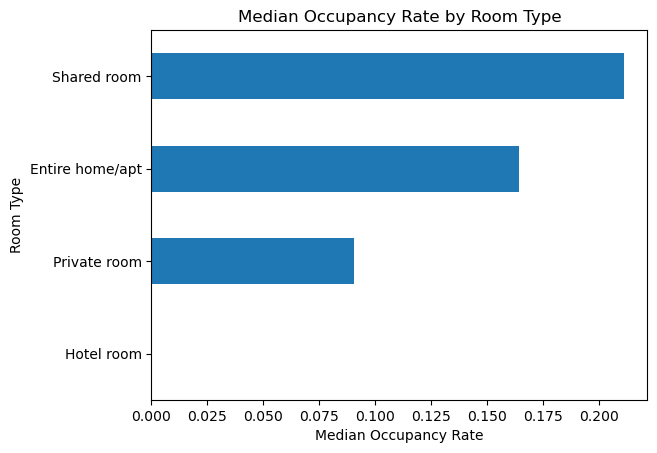

room_type
Hotel room         0.000000
Private room       0.090411
Entire home/apt    0.164384
Shared room        0.210959
Name: occupancy_rate, dtype: float64

In [38]:
# Compare median occupancy across room types to see which listing formats perform best
room_occ = (
    airbnb.groupby('room_type')['occupancy_rate']
    .median()
    .sort_values()
)

room_occ.plot(kind='barh')
plt.title("Median Occupancy Rate by Room Type")
plt.xlabel("Median Occupancy Rate")
plt.ylabel("Room Type")
plt.show()

room_occ

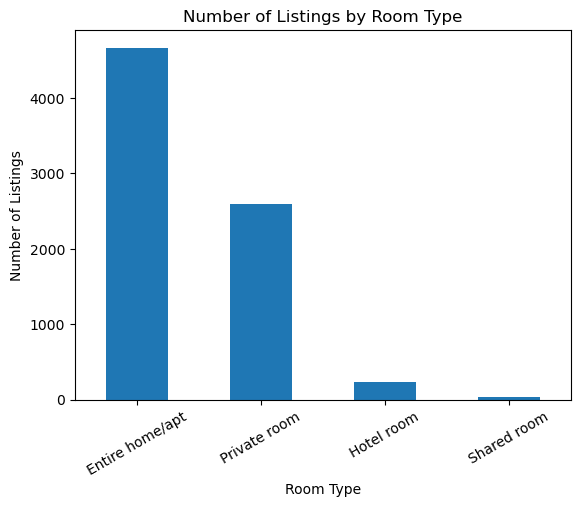

room_type
Entire home/apt    4669
Private room       2599
Hotel room          233
Shared room          34
Name: count, dtype: int64

In [39]:
room_counts = airbnb['room_type'].value_counts()

room_counts.plot(kind='bar')
plt.title("Number of Listings by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")
plt.xticks(rotation=30)
plt.show()

room_counts


Room type creates a clear occupancy gap in this dataset. Shared rooms show the highest median occupancy rate, but they represent a much smaller portion of the dataset than entire homes or private rooms. Entire homes still look like the more credible high-performing category because they combine relatively strong occupancy with a much larger sample size.

### 3. Which neighborhoods appear to sustain stronger occupancy?

Neighborhood matters both for performance and for market positioning, so the analysis focuses on higher-volume areas rather than very small neighborhood groups.

In [40]:
# Compare neighborhoods while filtering out very small groups to keep the ranking more stable
neigh_occ = (
    airbnb.groupby('neighbourhood_cleansed')
    .agg(
        listings=('id', 'count'),
        median_occupancy_rate=('occupancy_rate', 'median')
    )
    .query('listings >= 15')
    .sort_values('median_occupancy_rate', ascending=False)
    .head(15)
)

neigh_occ

,listings,median_occupancy_rate
neighbourhood_cleansed,,
Visitacion Valley,61,0.657534
Outer Richmond,192,0.493151
Outer Sunset,340,0.391781
Parkside,127,0.361644
Excelsior,147,0.361644
Potrero Hill,140,0.346575
Outer Mission,139,0.331507
Crocker Amazon,51,0.328767
Castro/Upper Market,294,0.328767


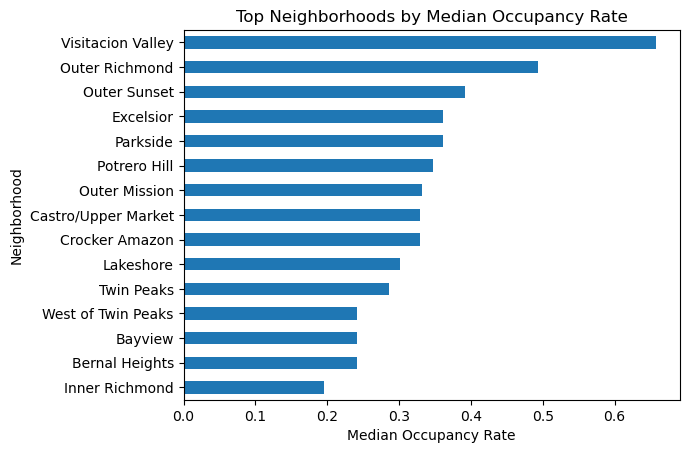

In [41]:
# Plot the top neighborhoods by median occupancy rate for easier comparison
neigh_occ.sort_values('median_occupancy_rate').plot(
    kind='barh',
    y='median_occupancy_rate',
    legend=False
)
plt.title("Top Neighborhoods by Median Occupancy Rate")
plt.xlabel("Median Occupancy Rate")
plt.ylabel("Neighborhood")
plt.show()

Neighborhood appears to matter meaningfully, with several areas standing out even after filtering for a minimum number of listings. Using median occupancy rate instead of raw occupied nights makes these comparisons easier to interpret and better aligned with the project goal.

### 4. Does guest capacity help explain occupancy?

Because exact guest-capacity values can be visually cluttered, listings are grouped into broader capacity buckets before median occupancy is compared.

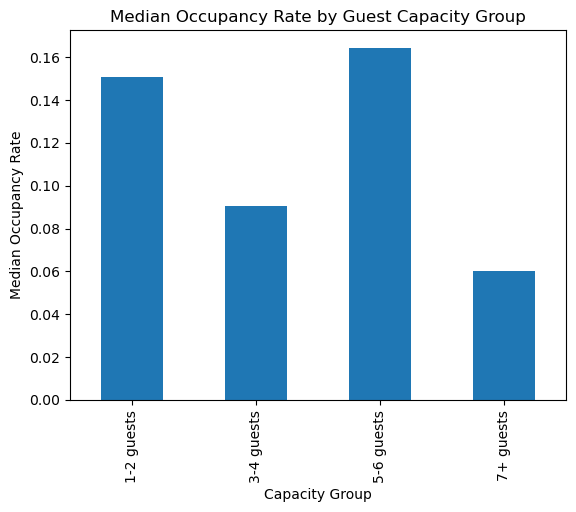

capacity_group
1-2 guests    0.150685
3-4 guests    0.090411
5-6 guests    0.164384
7+ guests     0.060274
Name: occupancy_rate, dtype: float64

In [42]:
# Group guest capacity into broader buckets so the pattern is easier to interpret
airbnb['capacity_group'] = pd.cut(
    airbnb['accommodates'],
    bins=[0, 2, 4, 6, 16],
    labels=['1-2 guests', '3-4 guests', '5-6 guests', '7+ guests']
)

acc_occ = (
    airbnb.groupby('capacity_group', observed=False)['occupancy_rate']
    .median()
    .dropna()
)

acc_occ.plot(kind='bar')
plt.title("Median Occupancy Rate by Guest Capacity Group")
plt.xlabel("Capacity Group")
plt.ylabel("Median Occupancy Rate")
plt.show()

acc_occ

Grouping capacity makes this comparison easier to trust than plotting every exact `accommodates` value. The binned view gives a clearer read on whether small, medium, or large listings tend to maintain stronger occupancy.

### 5. What does the room-type summary table add?

The table below combines occupancy, review volume, and ratings so room types can be compared using more than one metric at a time.

In [43]:
# Summarize room types using occupancy, review volume, and rating in one table
summary = (
    airbnb.groupby('room_type')
    .agg(
        listings=('id', 'count'),
        median_occ_nights=('occupied_nights', 'median'),
        median_occ_rate=('occupancy_rate', 'median'),
        median_reviews=('number_of_reviews', 'median'),
        median_rating=('review_scores_rating', 'median')
    )
    .sort_values('median_occ_rate', ascending=False)
)

summary

,listings,median_occ_nights,median_occ_rate,median_reviews,median_rating
room_type,,,,,
Shared room,34,77.0,0.210959,26.5,4.77
Entire home/apt,4669,60.0,0.164384,10.0,4.93
Private room,2599,33.0,0.090411,7.0,4.88
Hotel room,233,0.0,0.000000,0.0,4.67


The room-type summary table helps show why some categories need caution. For example, hotel rooms can show a review rating even when the median occupied nights and median review counts are 0, because ratings are calculated only from listings that have review-score data.

## 4. Follow-Up Checks

### 6. Which host-side factors look most important?

The next set of charts checks whether host-related signals such as superhost status, booking policies, and host acceptance behavior remain important once more context is added.

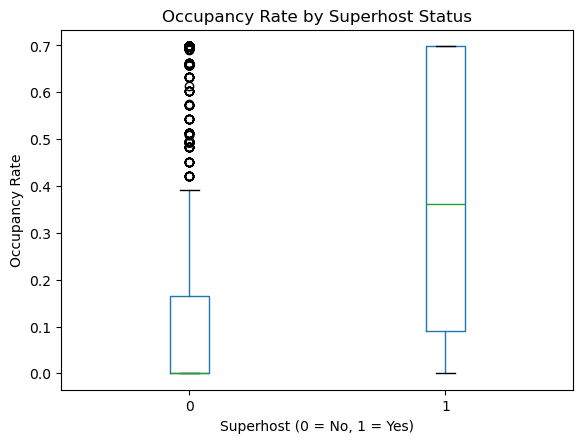

host_is_superhost
0    0.000000
1    0.361644
Name: occupancy_rate, dtype: float64

In [44]:
# Test whether superhost listings tend to have higher occupancy than non-superhost listings
airbnb.boxplot(column='occupancy_rate', by='host_is_superhost', grid=False)
plt.title("Occupancy Rate by Superhost Status")
plt.suptitle("")
plt.xlabel("Superhost (0 = No, 1 = Yes)")
plt.ylabel("Occupancy Rate")
plt.show()

airbnb.groupby('host_is_superhost')['occupancy_rate'].median()

Superhost status is one of the clearest indicators of higher occupancy in the notebook. The gap between superhosts and non-superhosts suggests that higher host quality, greater responsiveness, and a better guest experience are associated with higher occupancy.

### 7. Do booking rules explain occupancy on their own?

This section tests whether instant booking and minimum-stay rules are associated with occupancy before controlling for other listing characteristics.

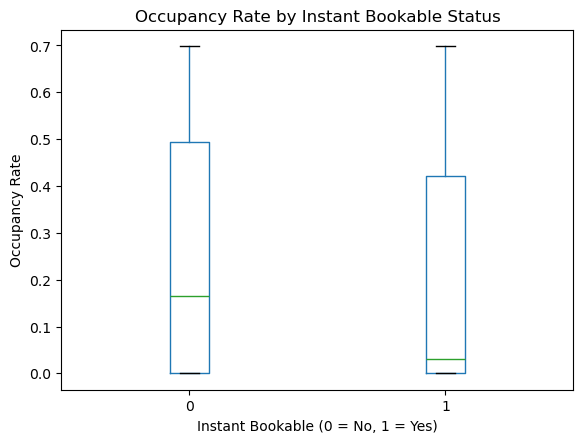

C:\Users\Matt\AppData\Local\Temp\ipykernel_11704\1821117799.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['room_type', 'min_stay_group'])['occupancy_rate']


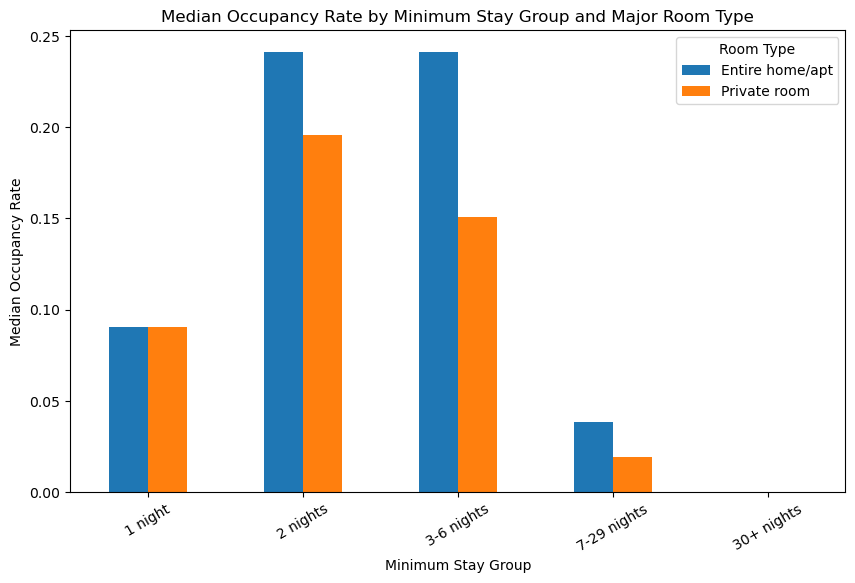

min_stay_group,1 night,2 nights,3-6 nights,7-29 nights,30+ nights
room_type,,,,,
Entire home/apt,0.090411,0.241096,0.241096,0.038356,0.0
Private room,0.090411,0.195890,0.150685,0.019178,0.0


In [52]:
# Compare instant-bookable listings and then test whether minimum-stay rules relate to occupancy
airbnb.boxplot(column='occupancy_rate', by='instant_bookable', grid=False)
plt.title("Occupancy Rate by Instant Bookable Status")
plt.suptitle("")
plt.xlabel("Instant Bookable (0 = No, 1 = Yes)")
plt.ylabel("Occupancy Rate")
plt.show()

airbnb.groupby('instant_bookable')['occupancy_rate'].median()


airbnb['min_stay_group'] = pd.cut(
    airbnb['minimum_nights'],
    bins=[0, 1, 2, 6, 29, 3650],
    labels=['1 night', '2 nights', '3-6 nights', '7-29 nights', '30+ nights']
)

major_room_types = ['Entire home/apt', 'Private room']

major_room_min_occ = (
    airbnb[airbnb['room_type'].isin(major_room_types)]
    .groupby(['room_type', 'min_stay_group'])['occupancy_rate']
    .median()
    .unstack()
)

major_room_min_occ.T.plot(kind='bar', figsize=(10, 6))
plt.title("Median Occupancy Rate by Minimum Stay Group and Major Room Type")
plt.xlabel("Minimum Stay Group")
plt.ylabel("Median Occupancy Rate")
plt.xticks(rotation=30)
plt.legend(title="Room Type")
plt.show()

major_room_min_occ

The instant-bookable comparison suggests that booking flexibility alone does not explain stronger occupancy in this dataset. Minimum-stay rules show a higher median occupancy rate for 2-night and 3-6-night stays, which is consistent across occupancy rates for entire homes/apts and private rooms. Hotels and Shared rooms were excluded due to the small sample size.

### 8. Does superhost status still matter within host-quality bins?

This check compares superhost and non-superhost listings within the same acceptance-rate groups to see whether superhost status still adds explanatory power.

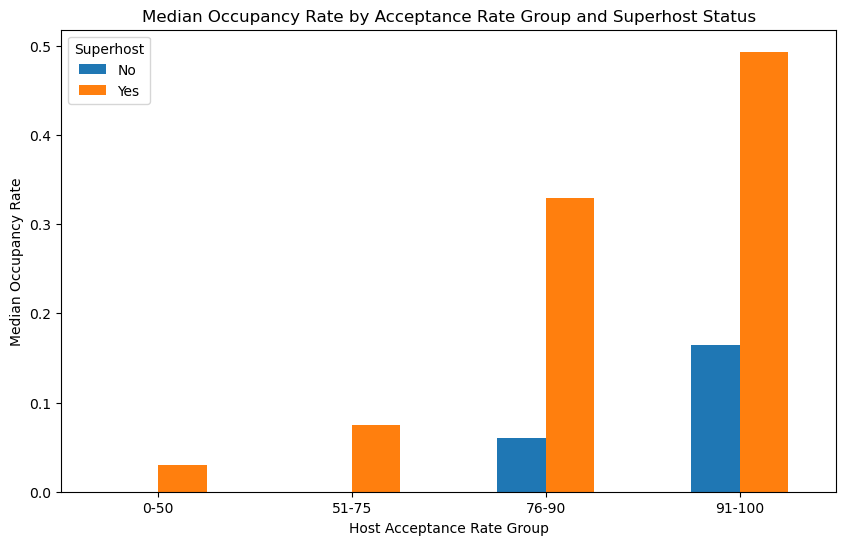

host_is_superhost,0,1
acceptance_rate_group,,
0-50,0.000000,0.030137
51-75,0.000000,0.075342
76-90,0.060274,0.328767
91-100,0.164384,0.493151


In [31]:
# Test whether the superhost gap remains after grouping listings by host acceptance rate
accept_df = airbnb.dropna(subset=['host_acceptance_rate', 'occupancy_rate']).copy()

accept_df['acceptance_rate_group'] = pd.cut(
    accept_df['host_acceptance_rate'],
    bins=[0, 50, 75, 90, 100],
    labels=['0-50', '51-75', '76-90', '91-100']
)

superhost_accept = (
    accept_df.groupby(['acceptance_rate_group', 'host_is_superhost'], observed=False)['occupancy_rate']
    .median()
    .unstack()
)

superhost_accept.plot(kind='bar', figsize=(10, 6))
plt.title("Median Occupancy Rate by Acceptance Rate Group and Superhost Status")
plt.xlabel("Host Acceptance Rate Group")
plt.ylabel("Median Occupancy Rate")
plt.xticks(rotation=0)
plt.legend(title="Superhost", labels=['No', 'Yes'])
plt.show()

superhost_accept


The acceptance-rate bins reinforce the superhost story rather than replacing it. Occupancy tends to improve as host acceptance rises, and superhosts remain above non-superhosts within every acceptance-rate group, making superhost status look like a consistently positive signal.

### 9. Does review activity strengthen or weaken the superhost gap?

Review activity is closely related to occupancy, so this section checks whether the superhost gap stays visible even when listings are grouped by reviews per month.

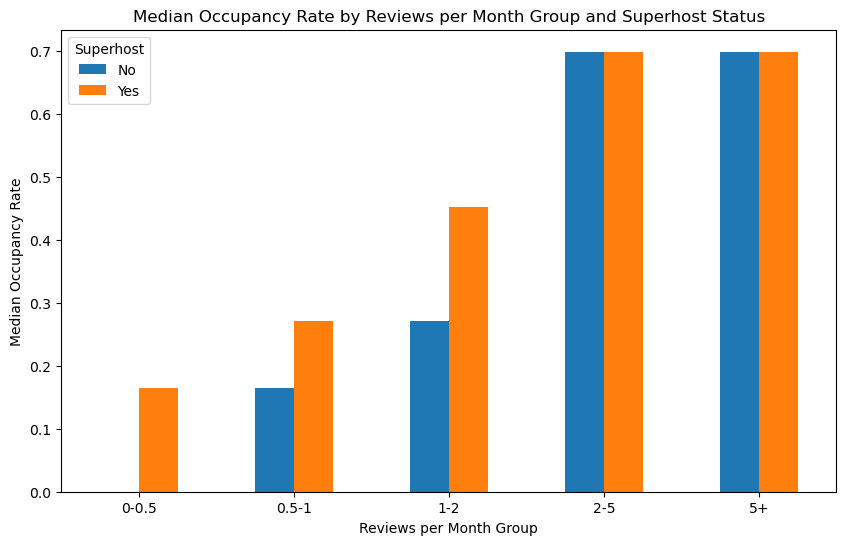

host_is_superhost,0,1
reviews_pm_group,,
0-0.5,0.000000,0.164384
0.5-1,0.164384,0.271233
1-2,0.271233,0.452055
2-5,0.698630,0.698630
5+,0.698630,0.698630


In [53]:
# Compare superhost and non-superhost occupancy across different levels of review activity
rpm_df = airbnb.dropna(subset=['reviews_per_month', 'occupancy_rate']).copy()

rpm_df['reviews_pm_group'] = pd.cut(
    rpm_df['reviews_per_month'],
    bins=[0, 0.5, 1, 2, 5, 50],
    labels=['0-0.5', '0.5-1', '1-2', '2-5', '5+']
)

superhost_rpm = (
    rpm_df.groupby(['reviews_pm_group', 'host_is_superhost'], observed=False)['occupancy_rate']
    .median()
    .unstack()
)

superhost_rpm.plot(kind='bar', figsize=(10, 6))
plt.title("Median Occupancy Rate by Reviews per Month Group and Superhost Status")
plt.xlabel("Reviews per Month Group")
plt.ylabel("Median Occupancy Rate")
plt.xticks(rotation=0)
plt.legend(title="Superhost", labels=['No', 'Yes'])
plt.show()

superhost_rpm


Reviews-per-month is strongly associated with occupancy, which is expected because listings with more booking activity also tend to generate more reviews. The superhost gap is still visible in lower and mid review-activity groups, but the relationship should be interpreted as a strong association rather than clear evidence of causation.

### 10. What do the supporting tables add?

The tables below combine multiple host-quality and location signals in one place. They are meant to support the chart-based findings rather than replace them.

In [54]:
# Build a compact summary table of host-quality signals by superhost status
superhost_host_quality = (
    airbnb.groupby('host_is_superhost')
    .agg(
        listings=('id', 'count'),
        median_occupancy_rate=('occupancy_rate', 'median'),
        median_response_rate=('host_response_rate', 'median'),
        median_acceptance_rate=('host_acceptance_rate', 'median'),
        median_reviews=('number_of_reviews', 'median'),
        median_reviews_per_month=('reviews_per_month', 'median')
    )
)

superhost_host_quality


,listings,median_occupancy_rate,median_response_rate,median_acceptance_rate,median_reviews,median_reviews_per_month
host_is_superhost,,,,,,
0,4283,0.000000,100.0,92.0,2.0,0.29
1,3252,0.361644,100.0,98.0,28.0,0.83


In [30]:
# Drill into the highest-volume neighborhoods to see how room type and superhost status interact
superhost_detail = (
    airbnb[airbnb['neighbourhood_cleansed'].isin(top_neighborhoods)]
    .groupby(['neighbourhood_cleansed', 'room_type', 'host_is_superhost'])
    .agg(
        listings=('id', 'count'),
        median_occupancy_rate=('occupancy_rate', 'median')
    )
    .query('listings >= 10')
    .sort_values('median_occupancy_rate', ascending=False)
)

superhost_detail.head(20)


listings  \
neighbourhood_cleansed room_type       host_is_superhost             
Outer Sunset           Private room    1                        72   
                       Entire home/apt 1                       104   
Castro/Upper Market    Entire home/apt 1                       133   
South of Market        Private room    1                        54   
Western Addition       Private room    1                       111   
Bernal Heights         Private room    1                        30   
Western Addition       Entire home/apt 1                       128   
Mission                Entire home/apt 1                       141   
Bernal Heights         Entire home/apt 1                       106   
Mission                Private room    1                        89   
South of Market        Entire home/apt 1                       119   
Castro/Upper Market    Private room    1                        44   
North Beach            Entire home/apt 1                        60   
Nob Hill               Private room    1                        21   
                       Entire home/apt 1                        86   
Financial District     Private room    1                        25   
Outer Sunset           Entire home/apt 0                        90   
South of Market        Private room    0                       106   
Bernal Heights         Entire home/apt 0                        86   
Outer Sunset           Private room    0                        73   

                                                          median_occupancy_rate  
neighbourhood_cleansed room_type       host_is_superhost                         
Outer Sunset           Private room    1                               0.698630  
                       Entire home/apt 1                               0.698630  
Castro/Upper Market    Entire home/apt 1                               0.512329  
South of Market        Private room    1                               0.487671  
Western Addition       Private room    1                               0.482192  
Bernal Heights         Private room    1                               0.467123  
Western Addition       Entire home/apt 1                               0.467123  
Mission                Entire home/apt 1                               0.452055  
Bernal Heights         Entire home/apt 1                               0.452055  
Mission                Private room    1                               0.452055  
South of Market        Entire home/apt 1                               0.421918  
Castro/Upper Market    Private room    1                               0.421918  
North Beach            Entire home/apt 1                               0.328767  
Nob Hill               Private room    1                               0.301370  
                       Entire home/apt 1                               0.164384  
Financial District     Private room    1                               0.164384  
Outer Sunset           Entire home/apt 0                               0.157534  
South of Market        Private room    0                               0.090411  
Bernal Heights         Entire home/apt 0                               0.090411  
Outer Sunset           Private room    0                               0.060274

The host-quality summary table is useful for combining several signals in one place. Taken together, these findings support the same pattern seen in the charts: superhosts tend to have higher occupancy, higher acceptance and response rates, and more review activity than non-superhosts.

The detailed neighborhood-room-type table is best treated as supporting evidence rather than an encompassing result. It shows that many of the strongest occupancy combinations come from superhost listings, which is consistent with the broader charts, but the table is mainly helpful for spotting specific high-performing segments.

## 5. Review Signals and Correlation

### 11. How do ratings and other numeric features relate to occupancy?

Review quality and correlation checks help round out the analysis, but they should be interpreted carefully. Review scores appear only weakly related to occupancy on their own, while the heatmap suggests that review activity, host acceptance behavior, and superhost-related signals are more strongly associated with stronger booking performance.

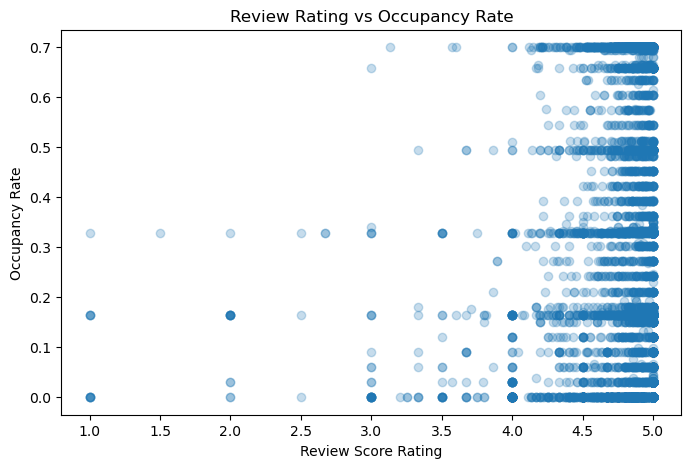

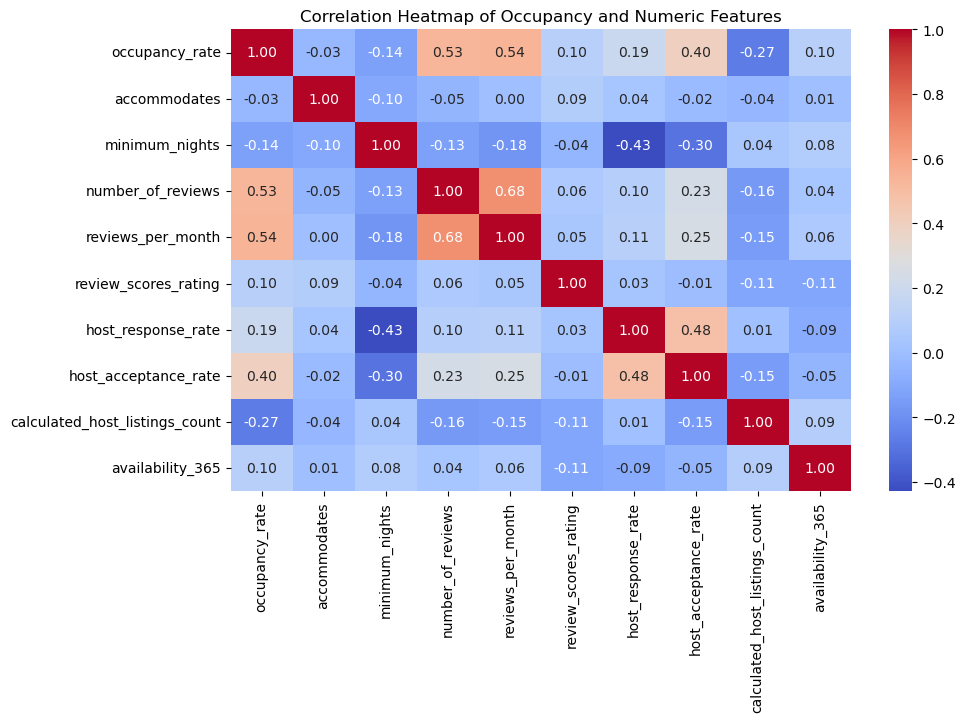

In [19]:
# Examine whether review ratings and other numeric features are associated with occupancy
review_df = airbnb.dropna(subset=['review_scores_rating', 'occupancy_rate']).copy()

plt.figure(figsize=(8, 5))
plt.scatter(review_df['review_scores_rating'], review_df['occupancy_rate'], alpha=0.25)
plt.title("Review Rating vs Occupancy Rate")
plt.xlabel("Review Score Rating")
plt.ylabel("Occupancy Rate")
plt.show()


corr_cols = [
    'occupancy_rate',
    'accommodates',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'review_scores_rating',
    'host_response_rate',
    'host_acceptance_rate',
    'calculated_host_listings_count',
    'availability_365'
]

corr = airbnb[corr_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Occupancy and Numeric Features")
plt.show()


## Key Findings

1. Occupancy varies widely across San Francisco Airbnb listings, suggesting that listing performance is uneven and that host/listing characteristics matter more than a single market-wide average.

2. Room type is one of the clearest structural factors associated with occupancy. Shared rooms show the highest median occupancy rate, but this category has a much smaller sample size, so the more reliable comparison is that entire homes generally outperform private rooms while also representing a much larger share of the dataset.

3. Neighborhood appears strongly associated with occupancy. Several neighborhoods consistently show higher median occupancy rates, suggesting that location plays an important role in listing performance.

4. Superhost status is one of the strongest and most consistent host-side signals in the analysis. Superhost listings show higher median occupancy overall, and this advantage remains evident even when comparing listings across major neighborhoods and host acceptance-rate groups.

5. Host acceptance rate is positively associated with occupancy. Listings in higher-acceptance-rate groups tend to show higher median occupancy, suggesting that hosts who accept more booking requests may be better positioned for stronger performance.

6. Review activity shows one of the strongest relationships with occupancy. Both number_of_reviews and reviews_per_month are strongly associated with higher occupancy, although these should be interpreted as performance-related signals rather than clear causal drivers.

7. Minimum-stay rules showed a clear pattern in the analysis, with 2-night and 3–6-night stays generally associated with stronger occupancy than longer minimum-stay groups. Across the largest room types, this pattern remained favorable overall, with 2-night stays performing especially well for private rooms and both 2-night and 3–6-night stays performing strongly for entire homes.

## Recommendations

1. Hosts should prioritize strengthening host performance factors, particularly **Superhost** status, booking acceptance behavior, and responsiveness. These characteristics appear to be among the most consistent host-side factors associated with higher occupancy in the dataset.

2. Guest experience should be treated as a priority in improving occupancy. Listings with stronger review activity tend to show substantially higher occupancy, suggesting that positive guest experiences and review generation may support stronger long-term booking performance.

3. Minimum-stay policies should be set with the listing’s room type and market segment in mind. In this analysis, shorter minimum stays, especially 2-night and 3–6-night requirements, were generally associated with stronger occupancy than longer minimum-stay rules, suggesting that greater booking flexibility may support stronger performance in the core market.

4. Hosts should benchmark their listings against comparable properties within the same room type and neighborhood rather than relying on citywide averages. Local market positioning appears to play an important role in explaining differences in occupancy.

5. For new or underperforming hosts, the clearest improvement opportunities lie in controllable factors: increasing acceptance rates, maintaining responsiveness, improving guest experience, and aligning listing strategy with the right local area.



## Limitations

1. `price` and `estimated_revenue_l365d` were unavailable in this dataset extract, so the analysis focuses on occupancy rather than pricing or revenue.
2. `estimated_occupancy_l365d` is an estimated measure rather than direct booking data.
3. The analysis is observational, so findings should be interpreted as associations rather than causation.
4. Some categories, such as shared rooms, have much smaller sample sizes and should be interpreted cautiously.

## Conclusion

This analysis shows that Airbnb occupancy in San Francisco is most strongly associated with a combination of listing structure, neighborhood context, and host-quality signals rather than any single universal rule. Room type, neighborhood, `Superhost` status, host acceptance behavior, and review activity all appear meaningfully linked to stronger booking performance.

Among the host-side factors, `Superhost` status stands out as one of the most consistent signals in the notebook, remaining associated with higher occupancy even after adding neighborhood and host-quality context. Minimum-stay rules told a more mixed story: although shorter stays looked favorable in the aggregate, that pattern weakened after subgroup checks, making it less reliable as a standalone recommendation. Overall, the strongest practical takeaway is that hosts should benchmark within the right local segment and focus on controllable quality signals such as acceptance behavior, responsiveness, and guest experience.